# Nonlinear Probabilistic Reconciliation via projection

## Introduction
This notebook demonstrates how to perform probabilistic nonlinear reconciliation using projection. To project the samples onto the coherent nonlinear manifold we use the [JNLR package](https://pypi.org/project/jnlr/) which is based on the projection algorithm developed in the paper "**Nonlinear reconciliation: Error reduction theorems**" by _Nespoli et.al (2026)_ published in [TMLR](https://openreview.net/forum?id=dXRWuogm3J).

For simplicity, we consider a synthetic dataset generated from a known nonlinear constraint defined as $U = f_u(B_1, B_2)$, where $f_u(.)$  generates a cone-shaped surface defined as $U = \sqrt{B_1^2 + B_2^2}$.

## Simulating the synthetic dataset
We simulate two independent AR(1) processes B1 and B2, which represent the free time series $B_1$ and $B_2$. We then apply the the nonlinear FTC ($f_u(.)$) to these processes to obtain the dependent time series $U$. The joint tuple $(U,B_1,B_2)$ are observations on the respective manifolds. Thus the total number of time series in this case is $n=3$.

In [53]:
#imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import jax.numpy as jnp
from sklearn.ensemble import RandomForestRegressor

plt.style.use("default")


In [55]:
# ----------------------------------------------------------------------
# Surface definition
# ----------------------------------------------------------------------

def surface_cone(b1, b2):
    """Cone: U = sqrt(B1^2 + B2^2)."""
    return np.sqrt(b1**2 + b2**2)

## Generate the free-level time series

def generate_independent_ar_processes(phi_1=0.9, phi_2=0.9, T=500, sigma=0.1, seed=42):
    """
    Generate two independent AR(1) processes B1 and B2.

    B1_t = phi_1 * B1_{t-1} + eps1_t
    B2_t = phi_2 * B2_{t-1} + eps2_t
    """
    rng = np.random.default_rng(seed)

    b1 = np.zeros(T)
    b2 = np.zeros(T)

    eps_1 = rng.normal(0, sigma, T)
    eps_2 = rng.normal(0, sigma, T)

    for t in range(1, T):
        b1[t] = phi_1 * b1[t - 1] + eps_1[t]
        b2[t] = phi_2 * b2[t - 1] + eps_2[t]

    return b1, b2

T = 500
phi_1 = 0.9
phi_2 = 0.9

b1, b2 = generate_independent_ar_processes(
    phi_1=phi_1,
    phi_2=phi_2,
    T=T,
    sigma=0.1,
    seed=42,
)

data_by_surface = {}

u = surface_cone(b1, b2)

df = pd.DataFrame({
        "U": u,
        "B1": b1,
        "B2": b2,
})


We can visualize the points on the surface as follows.

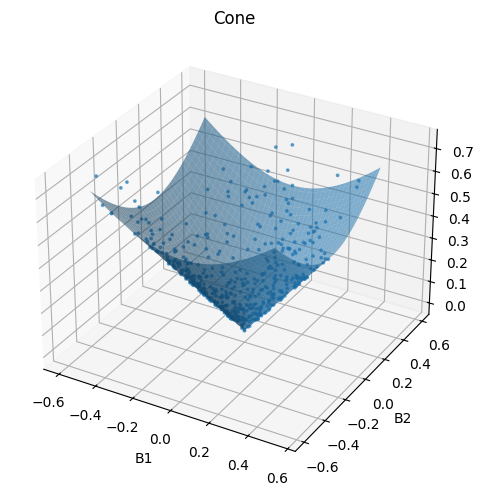

In [56]:
def plot_surface_with_samples(df, grid_n=80):

    b1_vals = df["B1"].to_numpy()
    b2_vals = df["B2"].to_numpy()
    u_vals = df["U"].to_numpy()

    x_grid = np.linspace(np.percentile(b1_vals, 1), np.percentile(b1_vals, 99), grid_n)
    y_grid = np.linspace(np.percentile(b2_vals, 1), np.percentile(b2_vals, 99), grid_n)

    X, Y = np.meshgrid(x_grid, y_grid)
    Z = surface_cone(X, Y)

    fig = plt.figure(figsize=(7, 5))
    ax = fig.add_subplot(111, projection="3d")

    ax.plot_surface(X, Y, Z, alpha=0.55, linewidth=0, antialiased=True)
    ax.scatter(b1_vals, b2_vals, u_vals, s=3, alpha=0.6)

    ax.set_title("Cone")
    ax.set_xlabel("B1")
    ax.set_ylabel("B2")
    ax.set_zlabel("U")

    plt.tight_layout()
    plt.show()

plot_surface_with_samples(df)
cone_data = df

## Generating base forecasts

Each time series is split into training and test sets using an 80\%--20\% chronological partition. Base forecasts are then constructed separately for $B_{1,t+h}$, $B_{2,t+h}$, and $U_{t+h}$ using only the training data (for $h=1$). We use a random forest regressor with lag 1 for forecasting each series. To obtain probabilistic base forecasts, we apply a joint residual bootstrap based on the in-sample residual vectors of the three series and obtain $N=1000$ sample points of the base forecast distribution.

In [57]:

def make_lagged_xy(series: pd.Series, p: int = 1):
    """
    Build one-step-ahead lagged features.

    X_t = [y_{t-1}, ..., y_{t-p}]
    y_t = y_t
    """
    X = pd.concat(
        [series.shift(lag) for lag in range(1, p + 1)],
        axis=1,
    )
    X.columns = [f"{series.name}_lag{lag}" for lag in range(1, p + 1)]
    y = series.copy()
    return X, y

def plot_constraint_surface(fig, b1_range, b2_range, n_grid=100):
    """
    Add the coherent constraint surface U = f(B1, B2) to a Plotly figure.
    """

    x = np.linspace(b1_range[0], b1_range[1], n_grid)
    y = np.linspace(b2_range[0], b2_range[1], n_grid)
    X, Y = np.meshgrid(x, y)
    Z = surface_cone(X, Y)

    fig.add_trace(
        go.Surface(
            x=X,
            y=Y,
            z=Z,
            opacity=0.35,
            colorscale="Blues",
            showscale=False,
            name="constraint surface",
        )
    )

# ============================================================
# Random Forest forecasting + joint residual bootstrap
# ============================================================

def fit_predictive_model(
    data,
    tr_ratio=0.8,
    lag_order=1,
    n_estimators=100,
    criterion="squared_error",
    n_samples=1000,
    random_state=42,
    make_plots=True,
):
    """
    Fit independent Random Forest models for U, B1, and B2.

    Then generate probabilistic forecasts using joint residual bootstrapping,
    preserving empirical dependence among residuals of U, B1, and B2.

    Returns
    -------
    base_fc : np.ndarray
        Forecast samples with shape (3, H, n_samples), ordered as [U, B1, B2].

    rf_residuals : np.ndarray
        Training residuals with shape (3, n_train_valid).

    det_forecasts : pd.DataFrame
        Deterministic point forecasts for the test period.

    df_te : pd.DataFrame
        Test data.
    """
    rng = np.random.default_rng(random_state)

    data = data[["U", "B1", "B2"]].copy()

    split_idx = int(tr_ratio * len(data))
    df_tr = data.iloc[:split_idx]
    df_te = data.iloc[split_idx:]

    y_hat_tr = pd.DataFrame(index=df_tr.index, columns=data.columns, dtype=float)
    y_hat_te = pd.DataFrame(index=df_te.index, columns=data.columns, dtype=float)

    # --------------------------------------------------------
    # Fit one model per series
    # --------------------------------------------------------
    for col in data.columns:
        # Training features
        X_tr, y_tr = make_lagged_xy(df_tr[col], p=lag_order)
        valid_tr = X_tr.index[X_tr.notna().all(axis=1) & y_tr.notna()]

        model = RandomForestRegressor(
            n_estimators=n_estimators,
            criterion=criterion,
            random_state=random_state,
            n_jobs=-1,
        )

        model.fit(X_tr.loc[valid_tr], y_tr.loc[valid_tr])
        y_hat_tr.loc[valid_tr, col] = model.predict(X_tr.loc[valid_tr])

        # Test features: prepend last training observations so first test lag is valid
        extended_series = pd.concat([df_tr[col].iloc[-lag_order:], df_te[col]])
        X_ext, _ = make_lagged_xy(extended_series, p=lag_order)

        X_te = X_ext.loc[df_te.index]
        valid_te = X_te.index[X_te.notna().all(axis=1)]

        y_hat_te.loc[valid_te, col] = model.predict(X_te.loc[valid_te])

    # --------------------------------------------------------
    # Joint residual bootstrap
    # --------------------------------------------------------
    valid_residual_idx = y_hat_tr.dropna().index

    res_mat = (
        df_tr.loc[valid_residual_idx, ["U", "B1", "B2"]]
        - y_hat_tr.loc[valid_residual_idx, ["U", "B1", "B2"]]
    ).to_numpy()

    H = len(y_hat_te)
    bootstrap_idx = rng.integers(0, len(res_mat), size=(H, n_samples))

    # Shape: (H, n_samples, 3)
    eps = res_mat[bootstrap_idx]

    # Shape: (H, 1, 3)
    y_hat_te_point = y_hat_te[["U", "B1", "B2"]].to_numpy()[:, None, :]

    # Shape: (H, n_samples, 3)
    y_hat_te_samples_tm = y_hat_te_point + eps

    # Shape: (3, H, n_samples)
    base_fc = np.transpose(y_hat_te_samples_tm, (2, 0, 1))

    # Shape: (3, n_train_valid)
    rf_residuals = res_mat.T

    # --------------------------------------------------------
    # Plots
    # --------------------------------------------------------
    if make_plots:
        fig, ax = plt.subplots(figsize=(10, 5))

        colors = plt.get_cmap("tab10")

        for i, col in enumerate(data.columns):
            ax.plot(
                df_te.index,
                df_te[col],
                label=f"{col} observed",
                color=colors(i),
            )
            ax.plot(
                y_hat_te.index,
                y_hat_te[col],
                "--",
                label=f"{col} forecast",
                color=colors(i),
            )

        ax.set_title(f"Deterministic forecasts — Cone")
        ax.set_xlabel("time")
        ax.set_ylabel("value")
        ax.legend()
        plt.tight_layout()
        plt.show()

    return base_fc, rf_residuals, y_hat_te, df_te

We visualize the deterministic point forecasts below.

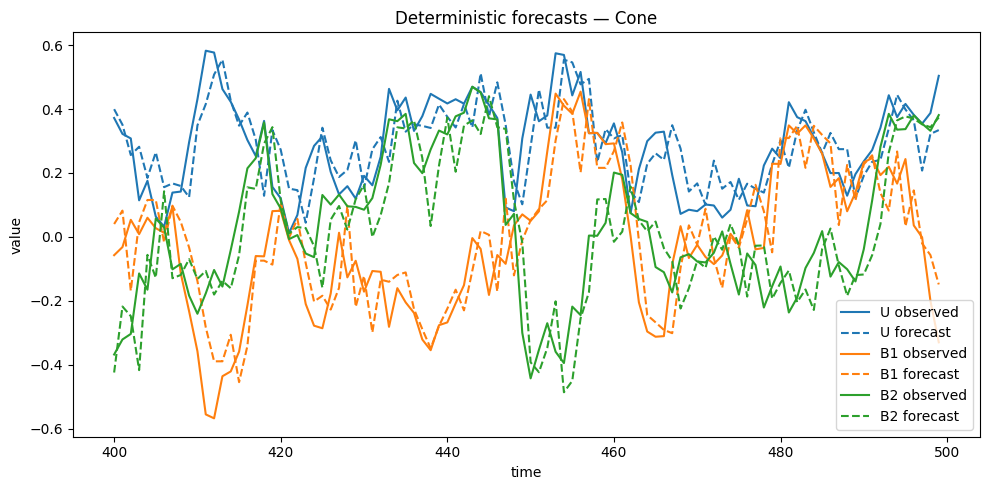

In [58]:
n_samples = 1000

base_fc_by_surface = {}
residuals_by_surface = {}
det_forecasts_by_surface = {}
test_data_by_surface = {}
data = cone_data

base_fc, residuals, det_forecasts, test_data = fit_predictive_model(
        data=data,
        tr_ratio=0.8,
        lag_order=1,
        n_estimators=100,
        criterion="squared_error",
        n_samples=n_samples,
        random_state=42,
        make_plots=True,
)

## Probabilistic reconciliation via projection

In [59]:
def sync_any(x):
    if hasattr(x, "block_until_ready"):
        x.block_until_ready()
    elif isinstance(x, dict):
        for v in x.values():
            sync_any(v)
    elif isinstance(x, (list, tuple)):
        for v in x:
            sync_any(v)
    return x

def f_cone_jax(b1, b2):
    """
    JAX version of the nonlinear coherent mapping U = f(B1, B2).
    """
    return jnp.sqrt(jnp.maximum(b1**2 + b2**2, 0.0))

base_fc = np.asarray(base_fc, dtype=np.float64)
n_vars, T, S = base_fc.shape
tr_res = np.asarray(residuals, dtype=np.float64)

# If residuals are given only once, repeat them across forecast horizons
tr_res = np.repeat(tr_res[:, None, :], T, axis=1)

We apply reocniliation via projection using different choices for the weight matrices $W$:
-   **ols**: $W = I$ with an underlying assumption of isotropic errors
-   **wls**: $W$ is set as a diagonal matrix hose entries are the estimated variances of the base forecast errors, so it accounts for the scale of the base forecast.
-   **full**: $W$ is estimated as the full covariance matrix of the base forecast errors, estimated via shrinkage, so it accounts for both heteroscedasticity and
the correlation structure between base forecasts.

To reconcile probabilistically for each rolling window, we use the  `reconc_nl_ols`  function. This takes samples in the order ($U,B$) with shape $(n,N)$, the constraint defined in this case as $U-f_u(B)=0$, and the $W$ matrix as inputs.
Note that the constraint should be defined as jax operators since the projection algorithm relies on JAX's autodiff capabilities to compute the Jacobian of the constraint. The output of the projection is a set of reconciled samples with the same shape (n,N) that are coherent with the nonlinear constraint.

In [62]:
## load the reconciliation functions
from nonlinear.projection import reconc_nl_ols
from core.covariance import _schafer_strimmer_cov as schafer_strimmer_cov, _to_precision
print("Shape of base forecast: ", base_fc.shape)

ols_fc = np.full_like(base_fc, np.nan)
full_fc = np.full_like(base_fc, np.nan)
wls_fc = np.full_like(base_fc, np.nan)

for t in range(T):
        # z_t has shape (S, 3)
        # columns are [U, B1, B2]
        z_t = base_fc[:, t, :].T.copy()

        # residuals at horizon t: shape (3, N_res)
        res_t = tr_res[:, t, :].copy()

        def constraint(z):
            u = z[0]
            b1 = z[1]
            b2 = z[2]

            return jnp.array([
                u - f_cone_jax(b1, b2)
            ])

        # Estimate covariance and precision matrix
        cov = schafer_strimmer_cov(res_t.T)["shrink_cov"]
        P = _to_precision(cov)

        # ----------------------------------------------------
        # OLS projection: no weighting matrix
        # ----------------------------------------------------
        out_ols = reconc_nl_ols(
            z_t,
            constraint,
            n_iter=25,
            seed=42,
        )
        sync_any(out_ols)
        ols_fc[:, t, :] = np.asarray(out_ols["reconciled_samples"])

        # ----------------------------------------------------
        # Full precision weighting
        # ----------------------------------------------------
        out_full = reconc_nl_ols(
            z_t,
            constraint,
            n_iter=25,
            seed=42,
            W=P,
        )
        sync_any(out_full)
        full_fc[:, t, :] = np.asarray(out_full["reconciled_samples"])

        # ----------------------------------------------------
        # Diagonal WLS weighting
        # ----------------------------------------------------
        out_wls = reconc_nl_ols(
            z_t,
            constraint,
            n_iter=25,
            seed=42,
            W=np.diag(np.diag(P)),
        )
        sync_any(out_wls)
        wls_fc[:, t, :] = np.asarray(out_wls["reconciled_samples"])

print("Shape of reconciled forecast - OLS:", ols_fc.shape)
print("Shape of reconciled forecast - WLS:", wls_fc.shape)
print("Shape of reconciled forecast - Full:", full_fc.shape)

Shape of base forecast:  (3, 100, 1000)
Shape of reconciled forecast - OLS: (3, 100, 1000)
Shape of reconciled forecast - WLS: (3, 100, 1000)
Shape of reconciled forecast - Full: (3, 100, 1000)


Thus we observe that the shapes of the reconciled forecasts are the same as the base forecasts.

## Scoring the forecasts

We compare the scores of the different forecasts using the energy score (ES) and the continuous ranked probability score (CRPS).
The relative scores are computed by dividing the ES and CRPS of each method by the ES and CRPS of the base forecast, respectively, to facilitate comparison.

In [61]:
from utils.scores import compute_es, compute_crps

projection_results_by_surface = {}
projection_scores_by_surface = {}

T = base_fc.shape[1]

gt_test = test_data[["U", "B1", "B2"]].iloc[:T].to_numpy().T

forecasts = {
        "base": base_fc,
        "ols": ols_fc,
        "wls": wls_fc,
        "full": full_fc,
}

es_scores = {}
crps_scores = {}

for key, arr in forecasts.items():
        es_scores[key] = compute_es(gt_test, arr)
        crps_scores[key] = compute_crps(gt_test, arr)

base_es = es_scores["base"]
base_crps = crps_scores["base"]

score_table = pd.DataFrame({
        "Energy Score": es_scores,
        "Relative ES": {
            key: val / base_es if base_es != 0 else np.nan
            for key, val in es_scores.items()
        },
        "CRPS": crps_scores,
        "Relative CRPS": {
            key: val / base_crps if base_crps != 0 else np.nan
            for key, val in crps_scores.items()
        },
})

display(score_table)

,Energy Score,Relative ES,CRPS,Relative CRPS
base,0.150156,1.000000,0.075584,1.000000
ols,0.145913,0.971744,0.075227,0.995285
wls,0.145900,0.971657,0.075198,0.994904
full,0.145752,0.970670,0.075123,0.993907
